找到 20 张标定图像
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/8.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/9.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/14.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/15.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/17.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/16.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/12.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/13.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/11.jpg 中找到角点
在 /Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding/10.jpg 中找到角点


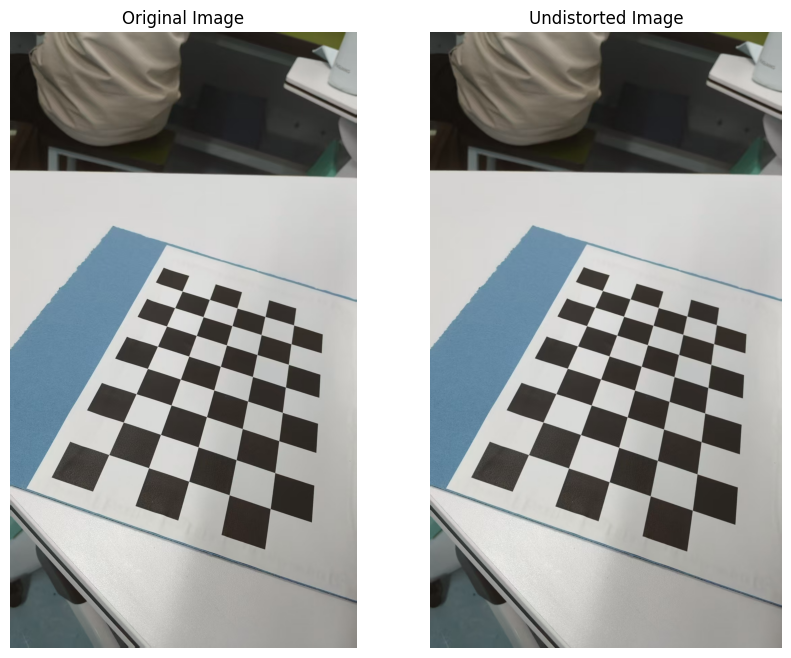

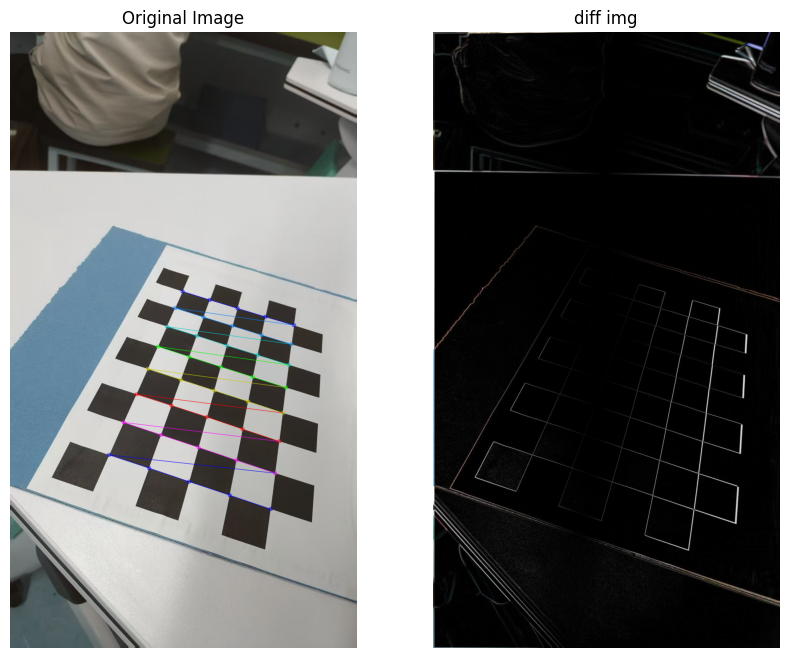

In [7]:
#张正友标定
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

#对象点
chessboard_size = (5, 8)  # 内角点数量（列，行）
square_size = 27.0
#实际标定使用的真实棋格的真实尺寸27mm

objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2) * square_size
objp[:, :2] *= square_size

#存储对象点和图像点的数组
objpoints = []  # 真实世界中的3D点
imgpoints = []  # 图像中的2D点

#读取所有标定图像
folder = r'/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 5/biaoding'
images = glob.glob(os.path.join(folder, '*.jpg')) \
       + glob.glob(os.path.join(folder, '*.png'))  # 两种后缀都读取

if len(images) == 0:
    print("未找到标定图像，请检查路径是否正确")
    exit()

print(f"找到 {len(images)} 张标定图像")

#遍历每张图像进行角点检测
for fname in images:
    img = cv2.imread(fname)
    if img is None:
        print(f"无法读取图像: {fname}")
        continue
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 查找棋格角点
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)
    
    if ret:
        print(f"在 {fname} 中找到角点")
        objpoints.append(objp)
        
        # 提高角点检测精度
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
                                    criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
        imgpoints.append(corners2)
        
        # 可视化角点
        # img = cv2.drawChessboardCorners(img, chessboard_size, corners2, ret)
        # plt.imshow(img)
        # plt.title('Corners')
    else:
        print(f"在 {fname} 中未找到角点")


#检查是否找到足够的图像进行标定
if len(objpoints) < 3:
    print("找到的可用图像太少，至少需要3张图像")
    exit()

print(f"使用 {len(objpoints)} 张图像进行标定")

#执行相机标定
print("开始相机标定...")
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

print("\n标定结果:")
print(f"重投影误差: {ret}")
print("相机内参矩阵:")
print(mtx)
print("畸变系数:")
print(dist)

#标定结果验证 - 计算重投影误差
mean_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
    mean_error += error

print(f"\n平均重投影误差: {mean_error / len(objpoints)} 像素")

#保存标定结果
np.savez('camera_calibration.npz', mtx=mtx, dist=dist, rvecs=rvecs, tvecs=tvecs)
print("\n标定结果已保存到 camera_calibration.npz")

#使用标定结果进行畸变校正
if len(images) > 0:
    # 使用第一张图像进行演示
    img = cv2.imread(images[0])
    h, w = img.shape[:2]
    
    # 优化相机矩阵
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    
    # 校正图像
    dst = cv2.undistort(img, mtx, dist, None, newcameramtx)
    
    # 裁剪图像
    x, y, w, h = roi
    dst = dst[y:y+h, x:x+w]
    
    # 显示结果
    fig, ax = plt.subplots(1, 2, figsize=(10,8))
    ax[0].imshow(img), ax[0].set_title('Original Image'), ax[0].axis('off')
    ax[1].imshow(dst), ax[1].set_title('Undistorted Image'), ax[1].axis('off')

    # ---------- 带角点的畸变校正 ----------
if len(images) > 0:
    img  = cv2.imread(images[0])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = img.shape[:2]

    # （1）先在校正前图上重新检角点并画上去
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size,
                                             cv2.CALIB_CB_ADAPTIVE_THRESH +
                                             cv2.CALIB_CB_NORMALIZE_IMAGE)
    if ret:                       # 如果找到就画
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1),
                                   (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
        cv2.drawChessboardCorners(img, chessboard_size, corners, True)

    # （2）再去畸变
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    dst = cv2.undistort(img, mtx, dist, None, newcameramtx)

    # （3）裁剪黑边（可选）
    x, y, w, h = roi
    dst = dst[y:y+h, x:x+w]

    # （4）显示 & 保存
    fig, ax = plt.subplots(1, 2, figsize=(10,8))
    ax[0].imshow(img), ax[0].set_title('Original Image'), ax[0].axis('off')
    ax[1].imshow(dst), ax[1].set_title('Undistorted Image'), ax[1].axis('off')

    # 生成未校正 & 校正两张图（同尺寸，不裁剪）
    img_raw   = cv2.imread(images[0])
    h, w = img_raw.shape[:2]
    map1, map2 = cv2.initUndistortRectifyMap(mtx, dist, None, mtx, (w, h), cv2.CV_16SC2)
    img_undist = cv2.remap(img_raw, map1, map2, cv2.INTER_LINEAR)

    # 计算差异并增强对比
    diff = cv2.absdiff(img_raw, img_undist)
    diff = cv2.convertScaleAbs(diff, alpha=1.5, beta=0)   # 放大 5 倍
    plt.imshow(diff)
    plt.title('diff img')

    print("\n标定完成！")

图1关键点: 5376 个，图2关键点: 7051 个
良好匹配对数： 101


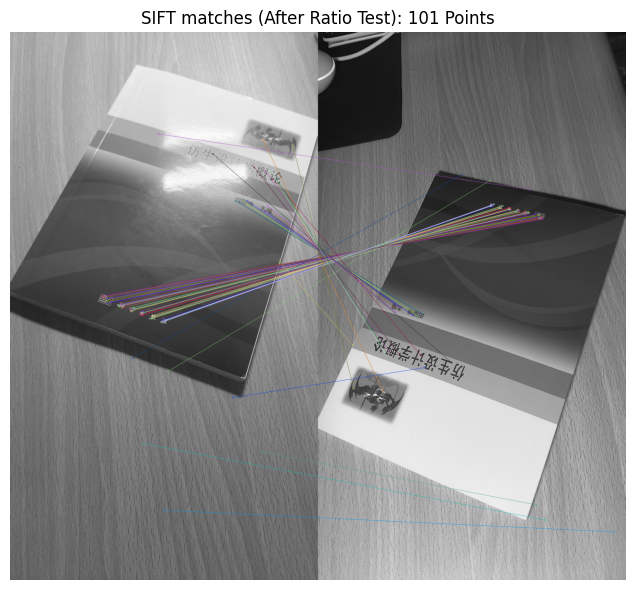

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读图
img1 = cv2.imread('Ang1.jpg', cv2.IMREAD_GRAYSCALE)  # 查询图
img2 = cv2.imread('Ang2.jpg', cv2.IMREAD_GRAYSCALE)  # 训练图
assert img1 is not None and img2 is not None, "无法读取图像，请检查路径！"

# 创建 SIFT 检测器
sift = cv2.SIFT_create()

# 检测关键点和描述子
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
print(f"图1关键点: {len(kp1)} 个，图2关键点: {len(kp2)} 个")

# 暴力匹配 + 比值测试
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    # Lowe 比值测试：最近距离 < 0.7*次近距离
    if m.distance < 0.7 * n.distance:
        good.append(m)
print("良好匹配对数：", len(good))

# 可视化
img_match = cv2.drawMatches(
    img1, kp1, img2, kp2, good, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12, 6))
plt.imshow(img_match[:, :, ::-1])  # BGR→RGB
plt.title(f"SIFT matches (After Ratio Test): {len(good)} Points")
plt.axis('off')
plt.tight_layout()
plt.show()